In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import signal

from few.waveform import GenerateEMRIWaveform

from few.utils.fdutils import GetFDWaveformFromFD, GetFDWaveformFromTD
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux, KerrEccEqFlux_nex
from few.utils.geodesic import get_separatrix
from few.utils.utility import get_p_at_t

from cycler import cycler
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['axes.prop_cycle'] = cycler(color=[
    "#373E8E",  # black
    "#b4af1f",  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
])

#From Ollie:
def units():

    G = 6.6726e-11
    c = 299792458
    Msun = 1.9889e30
    Gpc = 1.02938e17
    Msun_sec = G*Msun/(c**3)  # All solar masses in seconds
    Distance_sec = (3.08567818585e25/c)  # Distances in seconds
    return Distance_sec,Msun_sec

def risco(a):
    return get_separatrix(a,0,1)

def Omega(r,a):
        return (r**(3/2)+a)**-1 

def freq_m(r,a,M,m):
    _,M_SI = units()
    M_sec = M * M_SI
    
    return (m/(2*np.pi))*Omega(r,a)/M_sec

def optimum_sampling_rate(a,M,m):
    r_isco = risco(a)
    freq_max = freq_m(r_isco,a,M,m)
    f_s = 2 * freq_max
    delta_t = 1/f_s
    
    return delta_t

In [19]:
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux_nex",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)
traj_module = EMRIInspiral(func=KerrEccEqFlux_nex)

def wf_gen(n,e0,T,p0=None):


        # define the injection parameters
    m1 = 1e6  # central object mass (solar masses)
    a = 1-10**(-n)    # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform
    m2 = 10.0  
    p0 = p0  
    e0 = e0  

    x0 = 1.0         # initial cos(inclination) - will be ignored in Schwarzschild waveform
    qK = np.pi / 2   # polar spin angle
    phiK = np.pi / 2 # azimuthal viewing angle
    qS = np.pi / 3   # polar sky angle
    phiS = np.pi / 3 # azimuthal viewing angle
    dist = 1.0       # luminosity distance (Gpc)

    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_theta0 = 0.0
    Phi_r0 = np.pi / 3

    Tobs = T   
    if T>0.5:         
        dt = 1    
    elif T<1/365:
        dt=0.1
    else:
        dt=1   


    mode_selection_threshold = 1e-4 




    waveform_kwargs = {
        "T": Tobs,
        "dt": dt,
        "mode_selection_threshold": mode_selection_threshold,
    }

   
    if p0 is None:
        p0 = get_p_at_t(
            traj_module,
            Tobs*0.99999,
            [m1, m2, a, e0, 1.0],       
            index_of_p=3,               
            index_of_a=2,               
            index_of_e=4,               
            index_of_x=5,
            traj_kwargs={},
            xtol=2e-12,                 
            rtol=8.881784197001252e-16, 
            bounds=None,
        )
        print("New p0: ", p0)



    emri_injection_params = [
        m1,
        m2,
        a,
        p0,
        e0,
        x0,
        dist,
        qS,
        phiS,
        qK,
        phiK,
        Phi_phi0,
        Phi_theta0,
        Phi_r0,
    ]


    data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) 
    time_array = np.arange(0, len(data_channels_td[0])) * dt

    return time_array, data_channels_td

In [20]:
n=9
a=1-10**(-n)
e0=0.0
m1=1e6
m2=10


h=24*60   #numbver of hours
time_length = (1/365)*(h/24)

time1 = time.time()
t,wf = wf_gen(n,e0,time_length)
time2=time.time()
print(f"Took {time2-time1} seconds")

New p0:  3.744824574057762
Took 2.0540316104888916 seconds


In [21]:
data = wf1[0]
fs=1

f_spec, t_spec, Sxx_spec = scipy.signal.spectrogram(data, fs,  
                        window=('tukey', 1), nperseg=3000, 
                         noverlap=100, nfft=None, detrend='constant', 
                         return_onesided=True, scaling='density',
                         axis=- 1, mode='magnitude')

Text(0.5, 0.98, 'Spectogram for $(a,p_0,e_0,T) = (1-10^{-9}$, 3.75, 0.0, 60 days)')

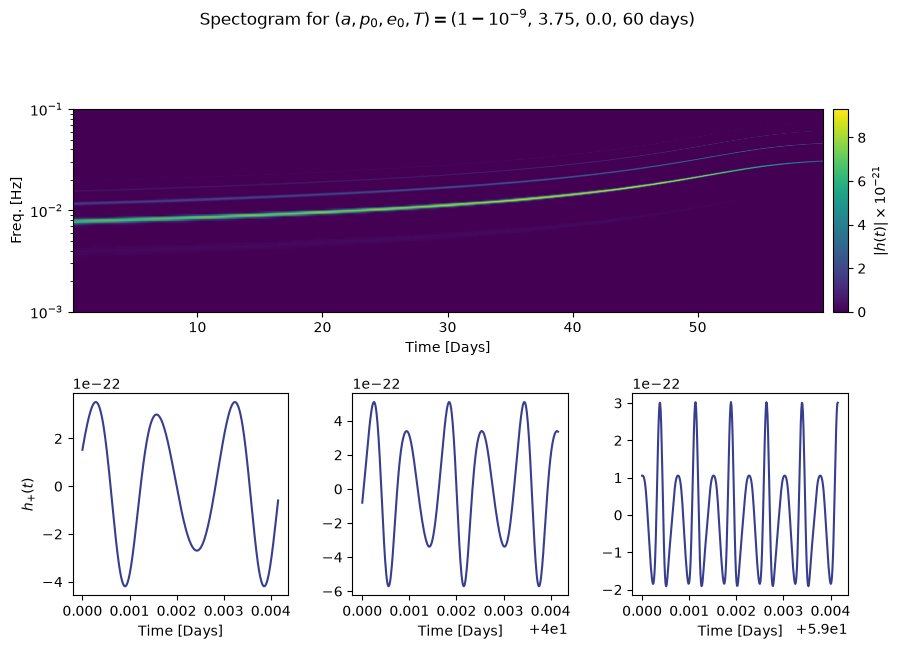

In [23]:
time_increments = [sec,min,hour,day,year] =   [1 ,       60 ,     (3600), (24*3600),24*2600*365 ]    
time_names =        ["seconds","minutes","hours","days", "years"]
i=3

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(3, 3, width_ratios=[1, 1,1])


ax_spect = fig.add_subplot(gs[0, :])
im = ax_spect.pcolormesh(t_spec/time_increments[i],f_spec, Sxx_spec*  1e21, alpha = 1,shading='gouraud')
divider = make_axes_locatable(ax_spect)
cax = divider.append_axes("right", size="2%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"$|h(t)| \times 10^{-21}$")
ax_spect.set_yscale("log")
ax_spect.set_ylim(1e-3,1e-1)

axs_snap  = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]

snap_times = [0,40*day,59*day]
snap_length = int(0.1*hour)

for ax,snap_time in zip(axs_snap,snap_times):
    ax.plot(t1[snap_time:snap_time+snap_length]/(time_increments[3]), wf1[0][snap_time:snap_time+snap_length] )
    ax.set_xlabel("Time [Days]")

axs_snap[0].set_ylabel(r"$h_{+}(t)$")
ax_spect.set_ylabel("Freq. [Hz]")
ax_spect.set_xlabel("Time [Days]")

plt.subplots_adjust(hspace=0.4)
plt.subplots_adjust(wspace=0.3)
plt.suptitle(fr"Spectogram for $(a,p_0,e_0,T) = (1-10^{{{-n}}}$, 3.75, {e0}, 60 days)")


#EDGE ON

#fig.savefig(f"Specto+Snapshots_n={n}_e0={e0}_T=60Days.png", dpi=300, bbox_inches="tight")